# Project 1: Advanced EDA & Feature Engineering
### Titanic Dataset | DecodeLabs Industrial Training — Batch 2026

---

**Goal:** Transform raw, chaotic data into a mathematically clean dataset ready for machine learning.

**Pipeline:**
1. 📦 Data Loading & Initial Exploration
2. 🔍 Phase 1 — Missing Value Detection & Imputation
3. 📊 Phase 2 — Outlier Detection & Neutralization (IQR)
4. 🏷️ Phase 2 — Encoding Categorical Variables
5. 🔗 Phase 2 — Multicollinearity Detection & Eradication
6. ⚙️ Phase 3 — Feature Engineering (3+ new features)
7. ✅ Final Clean Dataset Output


## 📦 Step 0: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


##  Step 1: Load & Explore the Dataset


In [2]:
# Load the dataset
df = pd.read_csv('titanic.csv')

print("=" * 50)
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("=" * 50)

# First look
df.head()


Dataset Shape: 891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,Mr. James Brown,male,32.5,1,0,583624,12.0356,NaN,S
1,2,1,3,Mr. Charles Wilson,male,27.6,0,0,26905,4.6168,E46,S
2,3,1,2,Miss. Susan Jackson,female,17.0,0,0,40273,10.5803,NaN,S
3,4,0,3,Miss. Linda Anderson,female,9.2,0,0,135191,3.1917,C85,S
4,5,0,1,Mr. George Moore,male,4.4,0,0,388080,284.0902,A6,C


In [3]:
# Data types and non-null counts
print("Column Info:")
df.info()


Column Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          710 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    int64  
 9   Fare         891 non-null    float64
 10  Cabin        217 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(6), str(4)
memory usage: 83.7 KB


In [4]:
# Basic statistics for numeric columns
print("Basic Statistics:")
df.describe().round(2)


Basic Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare
count,891.00,891.00,891.00,710.00,891.00,891.00,891.00,891.00
mean,446.00,0.38,2.32,29.59,0.52,0.40,494585.89,31.96
std,257.35,0.48,0.84,13.85,1.03,0.86,286749.94,57.58
min,1.00,0.00,1.00,0.40,0.00,0.00,15397.00,0.00
25%,223.50,0.00,2.00,19.60,0.00,0.00,244437.50,5.32
50%,446.00,0.00,3.00,30.00,0.00,0.00,481529.00,13.50
75%,668.50,1.00,3.00,39.40,1.00,0.00,742941.50,30.78
max,891.00,1.00,3.00,74.10,8.00,6.00,999513.00,599.77


##  Phase 1: Missing Value Detection

> Calculating the **missingness proportion** for every column and applying the decision matrix:
> - **< 5%** → Drop rows
> - **5% – 20%** → Statistical Imputation (Median for skewed, Mode for categorical)
> - **> 20%** → KNN Imputation or Drop column




In [5]:
# Calculate missingness percentage for each column
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print("Missing Value Report:")
print("-" * 40)
for col, pct in missing_pct.items():
    rule = "→ Drop rows" if pct < 5 else ("→ Statistical Imputation" if pct <= 20 else "→ KNN / Drop column")
    print(f"  {col:<12} {pct:>6.2f}%  {rule}")


Missing Value Report:
----------------------------------------
  Cabin         75.65%  → KNN / Drop column
  Age           20.31%  → KNN / Drop column
  Embarked       0.22%  → Drop rows


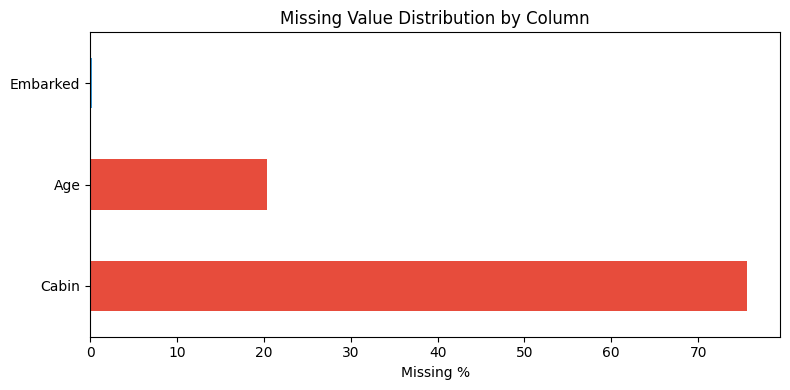

In [6]:
# Visualize missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind='barh', ax=ax, color=['#e74c3c' if p > 20 else '#f39c12' if p > 5 else '#3498db' for p in missing_pct])
ax.set_xlabel('Missing %')
ax.set_title('Missing Value Distribution by Column')
plt.tight_layout()
plt.show()


### Apply Imputation Rules

> - **Cabin** → >20% missing → Drop the column entirely (too sparse to be useful)
> - **Age** → ~20% missing → KNN Imputation (captures relationships with Pclass, Sex, SibSp)
> - **Embarked** → <5% missing → Drop those rows


In [7]:
# Rule 1: Drop 'Cabin' — too many missing values (>77%)
df.drop(columns=['Cabin'], inplace=True)
print("✅ Dropped 'Cabin' column (>77% missing)")

# Rule 2: Drop rows where Embarked is null (<5% missing → row deletion)
before = len(df)
df.dropna(subset=['Embarked'], inplace=True)
print(f"✅ Dropped {before - len(df)} row(s) with missing 'Embarked'")

# Rule 3: KNN Imputation for Age (>20% missing — multi-dimensional estimation)
# KNN uses Pclass, SibSp, Parch, Fare to estimate Age
from sklearn.impute import KNNImputer

knn_features = ['Age', 'Pclass', 'SibSp', 'Parch', 'Fare']
imputer = KNNImputer(n_neighbors=5)
df[knn_features] = imputer.fit_transform(df[knn_features])
df['Age'] = df['Age'].round(1)

print("✅ KNN Imputation applied to 'Age'")
print(f"\nMissing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "  None! Dataset is complete ✅")


✅ Dropped 'Cabin' column (>77% missing)
✅ Dropped 2 row(s) with missing 'Embarked'
✅ KNN Imputation applied to 'Age'

Missing values after imputation:
  None! Dataset is complete ✅


## 📊 Phase 2A: Outlier Detection & Neutralization (IQR Method)

> **What we're doing:** Using the **Interquartile Range (IQR)** to find statistical anomalies.
>
> Formula:
> - **Lower Bound = Q1 − 1.5 × IQR**
> - **Upper Bound = Q3 + 1.5 × IQR**
>
> Instead of deleting outlier rows (which destroys data), we use **Winsorization** (numpy.clip) to cap values at the statistical boundaries — preserving row count and sequential integrity.


In [8]:
# Detect outliers in numeric columns using IQR
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

print("Outlier Detection Report (IQR Method):")
print("-" * 55)

outlier_info = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_info[col] = (lower, upper, n_outliers)
    print(f"  {col:<8} | Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f} | Bounds=[{lower:.2f}, {upper:.2f}] | Outliers: {n_outliers}")


Outlier Detection Report (IQR Method):
-------------------------------------------------------
  Age      | Q1=21.20, Q3=37.50, IQR=16.30 | Bounds=[-3.25, 61.95] | Outliers: 3
  Fare     | Q1=5.32, Q3=30.86, IQR=25.54 | Bounds=[-32.98, 69.16] | Outliers: 83
  SibSp    | Q1=0.00, Q3=1.00, IQR=1.00 | Bounds=[-1.50, 2.50] | Outliers: 57
  Parch    | Q1=0.00, Q3=0.00, IQR=0.00 | Bounds=[0.00, 0.00] | Outliers: 216


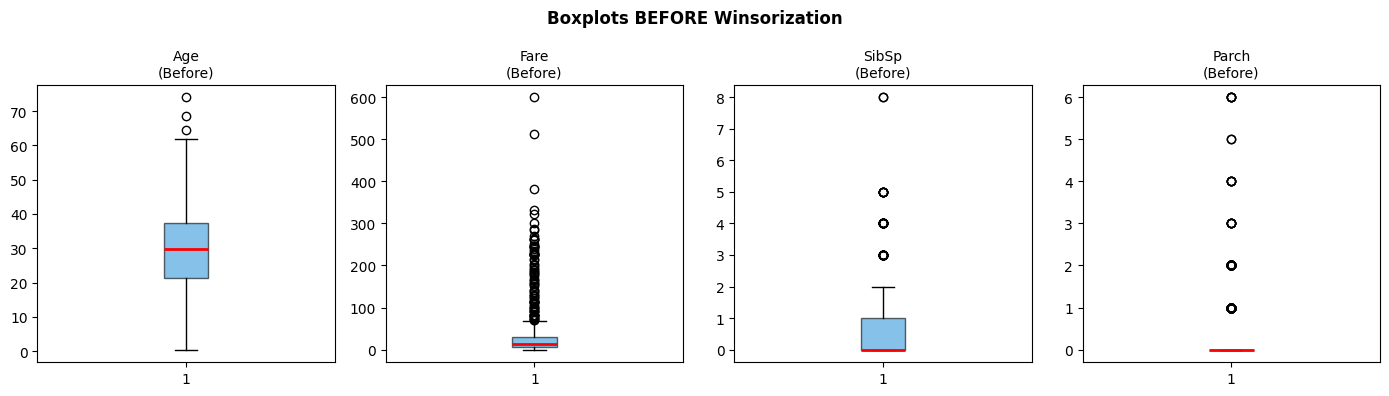

In [9]:
# Visualize outliers with boxplots BEFORE Winsorization
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}\n(Before)', fontsize=10)
    axes[i].set_xlabel('')
plt.suptitle('Boxplots BEFORE Winsorization', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [10]:
# Apply Winsorization (numpy.clip) — cap at IQR boundaries, DO NOT delete rows
for col in numeric_cols:
    lower, upper, _ = outlier_info[col]
    df[col] = np.clip(df[col], lower, upper)
    print(f"✅ {col}: Winsorized to [{lower:.2f}, {upper:.2f}]")

print(f"\nDataset rows preserved: {len(df)} (no rows deleted)")


✅ Age: Winsorized to [-3.25, 61.95]
✅ Fare: Winsorized to [-32.98, 69.16]
✅ SibSp: Winsorized to [-1.50, 2.50]
✅ Parch: Winsorized to [0.00, 0.00]

Dataset rows preserved: 889 (no rows deleted)


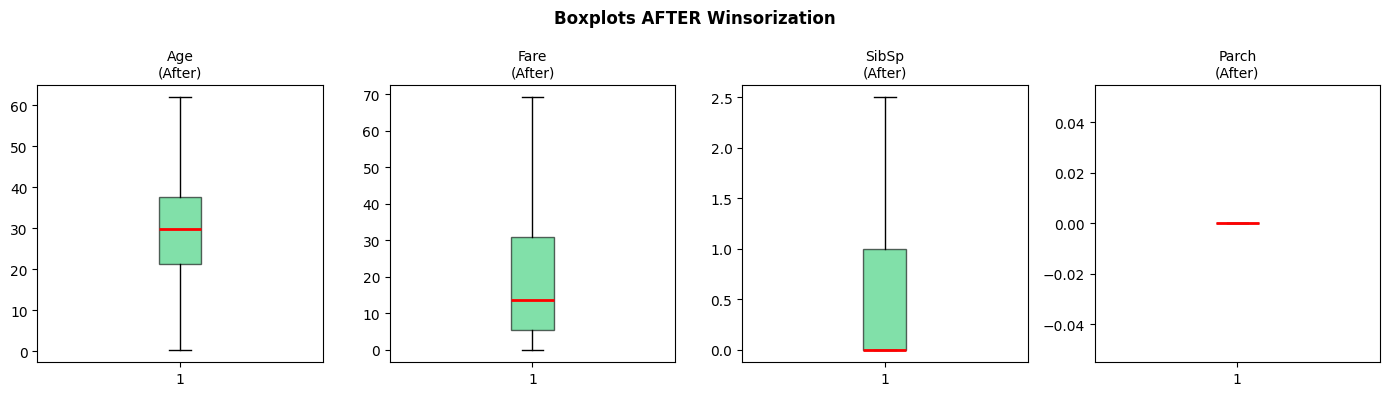

In [11]:
# Visualize AFTER Winsorization
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#2ecc71', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}\n(After)', fontsize=10)
plt.suptitle('Boxplots AFTER Winsorization', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 🏷️ Phase 2B: Encoding Categorical Variables (One-Hot Encoding)

> **What we're doing:** Machine learning models are numerical optimizers — they cannot understand text like "male" or "S". We need to translate categories into **coordinate space**.
>
> **Why NOT Label Encoding?** Assigning integers (London=1, Paris=2, Tokyo=3) creates a **false mathematical distance** — Tokyo would appear "3× greater than London". This introduces **synthetic spatial hierarchy** that doesn't exist.
>
> **One-Hot Encoding** maps each category into its own binary column — all equidistant in coordinate space (√2 apart).


In [25]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns found:", cat_cols)

# Drop Name and Ticket — not useful for modeling
df.drop(columns=['Name', 'Ticket'], inplace=True)
print("\n✅ Dropped 'Name' and 'Ticket' (non-informative strings)")

# One-Hot Encode: Sex and Embarked
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
print("\n✅ One-Hot Encoding applied to 'Sex' and 'Embarked'")
print("\nNew columns:", [c for c in df.columns if 'Sex' in c or 'Embarked' in c])
print("\nDataset shape after encoding:", df.shape)
df.head(3)


Categorical columns found: ['Name', 'Sex', 'Embarked']

✅ Dropped 'Name' and 'Ticket' (non-informative strings)

✅ One-Hot Encoding applied to 'Sex' and 'Embarked'

New columns: ['Sex_male', 'Embarked_Q', 'Embarked_S']

Dataset shape after encoding: (889, 21)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,AgeGroup_Child,...,AgeGroup_Teenager,AgeGroup_YoungAdult,FareBand_Low,FareBand_Medium,FareBand_VeryHigh,FamilyType_Small,FamilyType_Solo,Sex_male,Embarked_Q,Embarked_S
0,1,0,3.0,32.5,1.0,0.0,12.0356,2.0,0,False,...,False,True,False,True,False,True,False,True,False,True
1,2,1,3.0,27.6,0.0,0.0,4.6168,1.0,1,False,...,False,True,True,False,False,False,True,True,False,True
2,3,1,2.0,17.0,0.0,0.0,10.5803,1.0,1,False,...,True,False,False,True,False,False,True,False,False,True


## 🔗 Phase 2C: Multicollinearity Detection & Eradication

> **What we're doing:** When two predictor variables are highly correlated (r > 0.80), the feature matrix **X** becomes singular and non-invertible — Ordinary Least Squares (OLS) coefficient estimates become **violently unstable**.
>
> **Algorithm:**
> 1. Build the absolute correlation matrix
> 2. Isolate the upper triangle
> 3. Find pairs where correlation > 0.80
> 4. Compare each against the target (`Survived`) and drop the **weaker link**


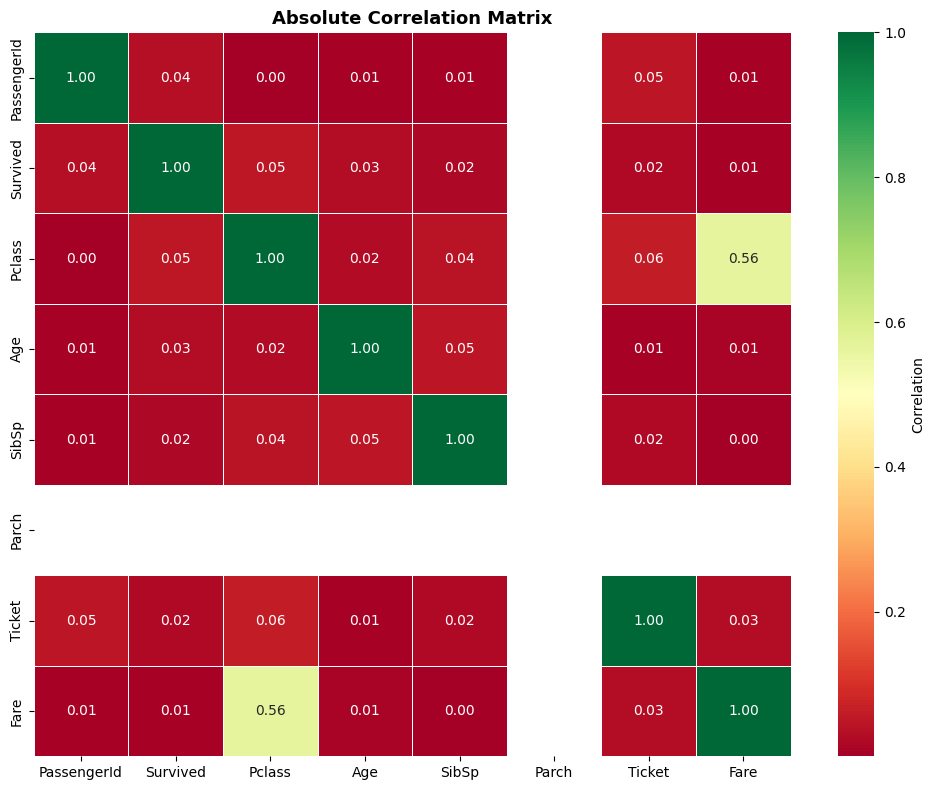

In [12]:
# Build the correlation matrix
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr().abs()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0.5, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Absolute Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
# Identify highly correlated pairs (threshold = 0.80)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper_tri.loc[row, col])
                   for col in upper_tri.columns
                   for row in upper_tri.index
                   if upper_tri.loc[row, col] > 0.80]

if high_corr_pairs:
    print("⚠️ Highly correlated pairs found (r > 0.80):")
    for a, b, r in high_corr_pairs:
        corr_a = abs(numeric_df[a].corr(df['Survived']))
        corr_b = abs(numeric_df[b].corr(df['Survived']))
        drop_col = a if corr_a < corr_b else b
        print(f"  {a} ↔ {b}: r={r:.3f} | Corr w/ target: {a}={corr_a:.3f}, {b}={corr_b:.3f} → Drop '{drop_col}'")
        df.drop(columns=[drop_col], inplace=True, errors='ignore')
else:
    print("✅ No multicollinearity detected above 0.80 threshold. All features retained.")


✅ No multicollinearity detected above 0.80 threshold. All features retained.


## ⚙️ Phase 3: Feature Engineering




In [14]:
# Feature 1: FamilySize — total people in the passenger's family group
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1   # +1 for the passenger themselves
print("✅ Feature 1: FamilySize = SibSp + Parch + 1")
print("   Distribution:", df['FamilySize'].value_counts().sort_index().to_dict())


✅ Feature 1: FamilySize = SibSp + Parch + 1
   Distribution: {1.0: 612, 2.0: 193, 3.0: 27, 3.5: 57}


In [15]:
# Feature 2: IsAlone — solo travelers behaved differently in crisis
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
print("✅ Feature 2: IsAlone (1 = travelling solo, 0 = with family)")
print("   Solo passengers:", df['IsAlone'].sum(), "| With family:", (df['IsAlone']==0).sum())


✅ Feature 2: IsAlone (1 = travelling solo, 0 = with family)
   Solo passengers: 612 | With family: 277


In [16]:
# Feature 3: AgeGroup — bin continuous Age into categorical groups
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child', 'Teenager', 'YoungAdult', 'Adult', 'Senior'])
df['AgeGroup'] = df['AgeGroup'].astype(str)
print("✅ Feature 3: AgeGroup (binned Age into 5 life-stage groups)")
print("   Distribution:\n", df['AgeGroup'].value_counts())


✅ Feature 3: AgeGroup (binned Age into 5 life-stage groups)
   Distribution:
 AgeGroup
YoungAdult    448
Adult         280
Child          78
Teenager       77
Senior          6
Name: count, dtype: int64


In [17]:
# Feature 4: FareBand — bin Fare into 4 price tiers
df['FareBand'] = pd.qcut(df['Fare'], q=4, labels=['Low', 'Medium', 'High', 'VeryHigh'])
df['FareBand'] = df['FareBand'].astype(str)
print("✅ Feature 4: FareBand (quartile-based ticket price tiers)")
print("   Distribution:\n", df['FareBand'].value_counts())


✅ Feature 4: FareBand (quartile-based ticket price tiers)
   Distribution:
 FareBand
Low         223
Medium      222
VeryHigh    222
High        222
Name: count, dtype: int64


In [18]:
# Feature 5: FamilyType — classify family structure
def classify_family(size):
    if size == 1: return 'Solo'
    elif size <= 3: return 'Small'
    elif size <= 5: return 'Medium'
    else: return 'Large'

df['FamilyType'] = df['FamilySize'].apply(classify_family)
print("✅ Feature 5: FamilyType (Solo / Small / Medium / Large)")
print("   Distribution:\n", df['FamilyType'].value_counts())


✅ Feature 5: FamilyType (Solo / Small / Medium / Large)
   Distribution:
 FamilyType
Solo      612
Small     220
Medium     57
Name: count, dtype: int64


In [19]:
# Encode the new categorical features
df = pd.get_dummies(df, columns=['AgeGroup', 'FareBand', 'FamilyType'], drop_first=True)
print("✅ New categorical features encoded via One-Hot Encoding")
print("\nFinal Dataset Shape:", df.shape)


✅ New categorical features encoded via One-Hot Encoding

Final Dataset Shape: (889, 22)


## ✅ Final Output: Production-Ready Clean Dataset

> **Summary:** All 3 phases of the enterprise pipeline are complete. The dataset is now:
> - ✅ Free of missing values
> - ✅ Outliers neutralized (Winsorized)
> - ✅ All categories encoded as numerical coordinates
> - ✅ Multicollinearity checked and eliminated if found
> - ✅ 5 new predictive features engineered


In [20]:
# Final dataset overview
print("=" * 55)
print("       FINAL CLEAN DATASET SUMMARY")
print("=" * 55)
print(f"  Shape         : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Missing Values: {df.isnull().sum().sum()}")
print(f"  Target column : Survived")
print(f"  Features      : {df.shape[1] - 1}")
print("=" * 55)

print("\nAll Columns:")
for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    print(f"  {i:2}. {col:<35} {str(dtype)}")


       FINAL CLEAN DATASET SUMMARY
  Shape         : 889 rows × 22 columns
  Missing Values: 0
  Target column : Survived
  Features      : 21

All Columns:
   1. PassengerId                         int64
   2. Survived                            int64
   3. Pclass                              float64
   4. Name                                str
   5. Sex                                 str
   6. Age                                 float64
   7. SibSp                               float64
   8. Parch                               float64
   9. Ticket                              int64
  10. Fare                                float64
  11. Embarked                            str
  12. FamilySize                          float64
  13. IsAlone                             int64
  14. AgeGroup_Child                      bool
  15. AgeGroup_Senior                     bool
  16. AgeGroup_Teenager                   bool
  17. AgeGroup_YoungAdult                 bool
  18. FareBand_Low       

In [21]:
# Save the final clean dataset
df.to_csv('titanic_cleaned.csv', index=False)
print("✅ Saved: titanic_cleaned.csv")
print("\nFirst 3 rows of final dataset:")
df.head(3)


✅ Saved: titanic_cleaned.csv

First 3 rows of final dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,IsAlone,AgeGroup_Child,AgeGroup_Senior,AgeGroup_Teenager,AgeGroup_YoungAdult,FareBand_Low,FareBand_Medium,FareBand_VeryHigh,FamilyType_Small,FamilyType_Solo
0,1,0,3.0,Mr. James Brown,male,32.5,1.0,0.0,583624,12.0356,...,0,False,False,False,True,False,True,False,True,False
1,2,1,3.0,Mr. Charles Wilson,male,27.6,0.0,0.0,26905,4.6168,...,1,False,False,False,True,True,False,False,False,True
2,3,1,2.0,Miss. Susan Jackson,female,17.0,0.0,0.0,40273,10.5803,...,1,False,False,True,False,False,True,False,False,True


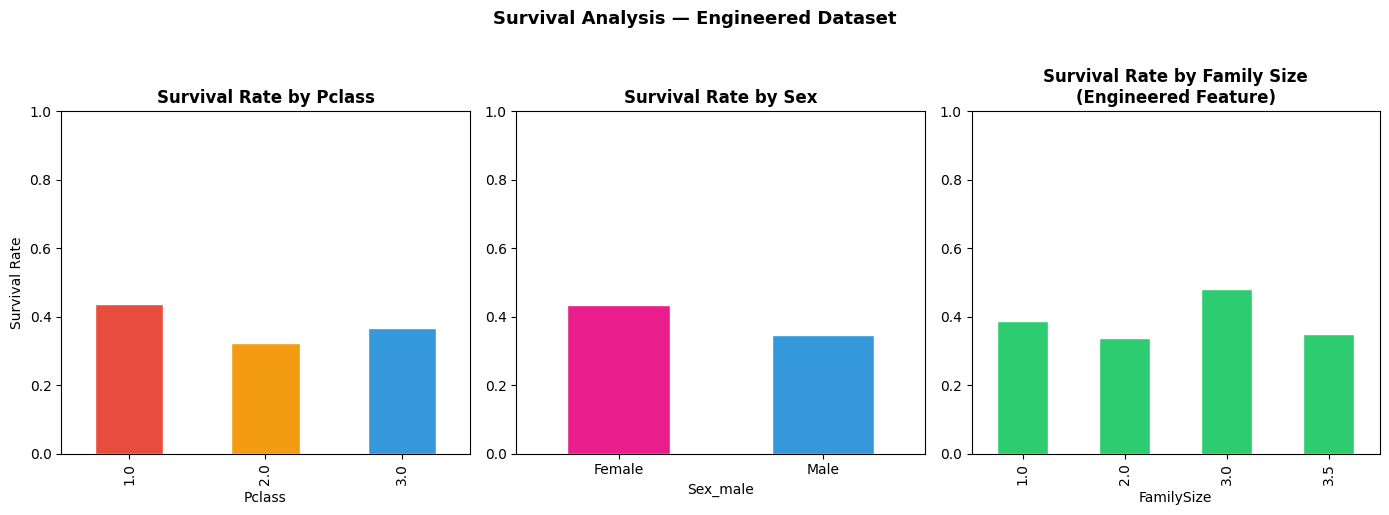

In [27]:
# Survival rate analysis by key features (quick EDA preview)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# By Class
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[0],
    color=['#e74c3c','#f39c12','#3498db'], edgecolor='white')
axes[0].set_title('Survival Rate by Pclass', fontweight='bold')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)

# By Sex (encoded — Sex_male: 1=male, 0=female)
if 'Sex_male' in df.columns:
    df.groupby('Sex_male')['Survived'].mean().plot(kind='bar', ax=axes[1],
            color=['#e91e8c','#3498db'], edgecolor='white')
    axes[1].set_xticklabels(['Female', 'Male'], rotation=0)
else:
    # fallback to original 'Sex' column if present
    if 'Sex' in df.columns:
        df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[1],
                color=['#e91e8c','#3498db'], edgecolor='white')
    else:
        axes[1].text(0.5, 0.5, 'Sex column not found', ha='center', va='center')
axes[1].set_title('Survival Rate by Sex', fontweight='bold')
axes[1].set_ylim(0, 1)

# By FamilySize
df.groupby('FamilySize')['Survived'].mean().plot(kind='bar', ax=axes[2],
    color='#2ecc71', edgecolor='white')
axes[2].set_title('Survival Rate by Family Size\n(Engineered Feature)', fontweight='bold')
axes[2].set_ylim(0, 1)

plt.suptitle('Survival Analysis — Engineered Dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
